### Task 5 - Model Iteration - BERT model 2


Importing all libraries that we will need to exxecute the code and run the model properly: 

In [11]:
import pandas as pd
import re
import torch
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)
from datasets import Dataset
from collections import Counter
import pandas as pd
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    AdamW,
    get_scheduler,
)
from torch.utils.data import Dataset, DataLoader
import torch
from tqdm import tqdm
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df = pd.read_csv("processed_group 9_url1.csv", encoding="utf-8")

# keeping only necessary columns
df = df.dropna(subset=["Corrected Sentence", "Emotion"])
df = df.drop_duplicates(subset=["Corrected Sentence", "Emotion"])

# balancing the emotion classes
# counting the number of samples per emotion label
emotion_counts = df["Emotion"].value_counts()
max_count = (
    emotion_counts.max()
)  # finding the maximum number of samples among all emotion classes
# resampling each emotion class to have the same number of samples as the most frequent class
df_balanced = pd.concat(
    [
        resample(
            df[df["Emotion"] == label],  # fltering rows of the current emotion class
            replace=True,  # allowing sampling with replacement (needed if class has fewer samples)
            n_samples=max_count, # setting the number of samples to match the most frequent class
            random_state=42,# reproducibility of results (same random samples each time)
        )
        for label in emotion_counts.index # iterating over each emotion class
    ]
)
# shuffling the dataset to avoid having all samples of the same class together
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# Encoding the emotion labels
label_encoder = LabelEncoder()
df_balanced["label"] = label_encoder.fit_transform(df_balanced["Emotion"])

# tokenization and encoding 
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
encodings = tokenizer(
    list(df_balanced["Corrected Sentence"]),
    truncation=True,
    padding=True,
    return_tensors="pt",
)
labels = torch.tensor(df_balanced["label"].values, dtype=torch.long)

# Train/test split
train_idx, test_idx = train_test_split(
    list(range(len(df_balanced))),
    test_size=0.2,
    stratify=df_balanced["label"],
    random_state=42,
)
train_encodings = {k: v[train_idx] for k, v in encodings.items()}
test_encodings = {k: v[test_idx] for k, v in encodings.items()}
train_labels = labels[train_idx]
test_labels = labels[test_idx]


# Custom dataset class
class EmotionDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item["labels"] = self.labels[idx]
        return item


train_dataset = EmotionDataset(train_encodings, train_labels)
test_dataset = EmotionDataset(test_encodings, test_labels)

# Model, optimizer, scheduler setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased", num_labels=len(label_encoder.classes_)
)
model.to(device)

optimizer = AdamW(model.parameters(), lr=5e-5)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
num_training_steps = len(train_loader) * 4
lr_scheduler = get_scheduler(
    "linear", optimizer, num_warmup_steps=0, num_training_steps=num_training_steps
)

# Training loop
model.train()
for epoch in range(4):
    print(f"\nEpoch {epoch+1}/4")
    loop = tqdm(train_loader)
    for batch in loop:
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        lr_scheduler.step()
        optimizer.zero_grad()
        loop.set_description(f"Epoch {epoch+1}")
        loop.set_postfix(loss=loss.item())

print("\n✅ Training complete!")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
d:\anaconda\envs\block_c_y2\lib\site-packages\transformers\optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(



Epoch 1/4


Epoch 1: 100%|██████████| 132/132 [03:36<00:00,  1.64s/it, loss=0.242]



Epoch 2/4


Epoch 2: 100%|██████████| 132/132 [03:36<00:00,  1.64s/it, loss=0.141] 



Epoch 3/4


Epoch 3: 100%|██████████| 132/132 [03:37<00:00,  1.65s/it, loss=0.0231]



Epoch 4/4


Epoch 4: 100%|██████████| 132/132 [03:34<00:00,  1.62s/it, loss=0.0153]


✅ Training complete!


##### Evaluation of the model

In [13]:
from sklearn.metrics import accuracy_score

model.eval()
predictions = []
true_labels = []

with torch.no_grad():
    for batch in DataLoader(test_dataset, batch_size=16):
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        logits = outputs.logits
        predictions.extend(torch.argmax(logits, dim=1).cpu().numpy())
        true_labels.extend(batch["labels"].cpu().numpy())

acc = accuracy_score(true_labels, predictions)
print(f"\n🧪 Test Accuracy: {acc:.4f}")


🧪 Test Accuracy: 0.9527


Further evaluation of the model: 


📊 Model Evaluation Metrics:
Accuracy  : 0.9527
Precision : 0.9526
Recall    : 0.9527
F1-score  : 0.9522

🔍 Classification Report:
              precision    recall  f1-score   support

       anger       0.96      1.00      0.98        75
     disgust       0.99      1.00      0.99        75
        fear       1.00      1.00      1.00        75
   happiness       0.96      0.88      0.92        76
     neutral       0.87      0.86      0.86        76
     sadness       0.94      1.00      0.97        75
    surprise       0.96      0.93      0.95        76

    accuracy                           0.95       528
   macro avg       0.95      0.95      0.95       528
weighted avg       0.95      0.95      0.95       528

🧩 Confusion Matrix:
[[75  0  0  0  0  0  0]
 [ 0 75  0  0  0  0  0]
 [ 0  0 75  0  0  0  0]
 [ 2  0  0 67  7  0  0]
 [ 0  1  0  2 65  5  3]
 [ 0  0  0  0  0 75  0]
 [ 1  0  0  1  3  0 71]]


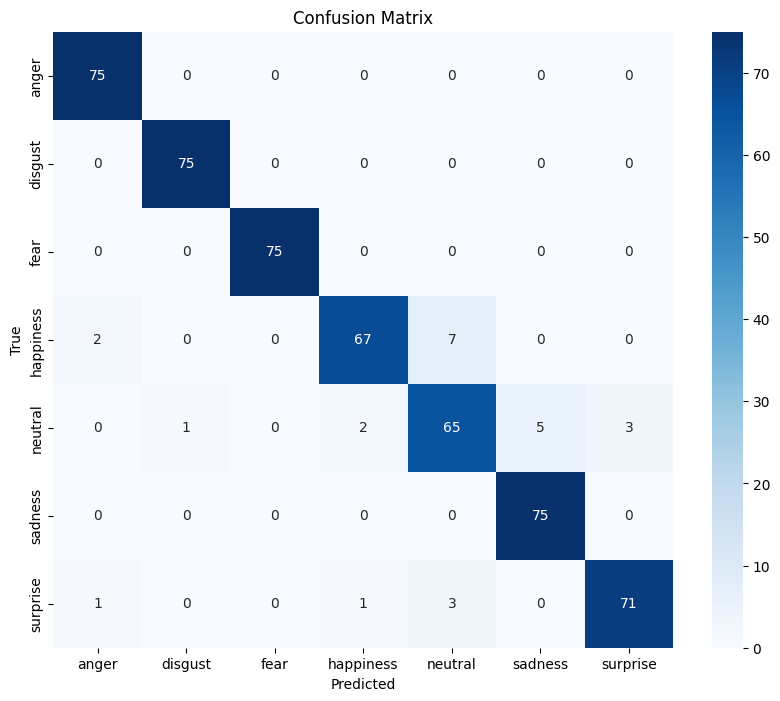

In [14]:
model.eval()
predictions = []
true_labels = []

with torch.no_grad():
    for batch in DataLoader(test_dataset, batch_size=16):
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        logits = outputs.logits
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        labels = batch["labels"].cpu().numpy()
        predictions.extend(preds)
        true_labels.extend(labels)

#convering to numpy arrays
y_pred = np.array(predictions)
y_true = np.array(true_labels)

#listing all he metrics
acc = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

#printing overall metrics
print("\n📊 Model Evaluation Metrics:")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")

#printing full classification report
class_names = label_encoder.classes_
print("\n🔍 Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

#display of the confusion matrix
print("🧩 Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))


# Plotting the confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

Saving the model: 

In [15]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer

model.save_pretrained("emotion_model_BERT5")
tokenizer.save_pretrained("emotion_model_BERT5_tokenizer")

('emotion_model_BERT5_tokenizer\\tokenizer_config.json',
 'emotion_model_BERT5_tokenizer\\special_tokens_map.json',
 'emotion_model_BERT5_tokenizer\\vocab.txt',
 'emotion_model_BERT5_tokenizer\\added_tokens.json')